# CPE 342 Machine Learning — Assignment 2: Training Models via Iterative Approach

**67070501042 วิศิษฐ์ สุวรรณเนาว์**

Gradient Descent — Fitting a Quadratic Model to Given Data

## 1. Problem Overview

Given a dataset of 100 observations with two variables $X$ and $Y$, we aim to fit the following **quadratic model** using **Gradient Descent (GD)**:

$$\hat{y} = C_0 + C_1 x^2$$

where:
- $C_0$ is the intercept (bias term)
- $C_1$ is the coefficient for the squared feature $x^2$

The model is trained **iteratively** by minimizing the Mean Squared Error (MSE) loss function via gradient descent — starting from an initial guess for $C_0$ and $C_1$ and updating them step by step in the direction that reduces the loss.

## 2. Data Loading & Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Load dataset ──────────────────────────────────────────────────────────────
# When running on Google Colab, upload the CSV file first or mount Google Drive.
# Example: from google.colab import files; files.upload()
df = pd.read_csv('CPE342_Assignment 2_Data.csv')

X = df['X'].values
Y = df['Y'].values
n = len(X)

print(f'Dataset shape : {df.shape}')
print(f'Number of obs : {n}')
print(f'X range       : [{X.min():.4f}, {X.max():.4f}]')
print(f'Y range       : [{Y.min():.4f}, {Y.max():.4f}]')
print()
print(df.describe().round(4))

Dataset shape : (100, 2)
Number of obs : 100
X range       : [0.0108, 4.9783]
Y range       : [0.9493, 1.9707]

              X         Y
count  100.0000  100.0000
mean     2.7306    1.1195
std      1.4451    0.2289
min      0.0108    0.9493
25%      1.6710    1.0031
50%      3.0813    1.0254
75%      3.8449    1.0899
max      4.9783    1.9707


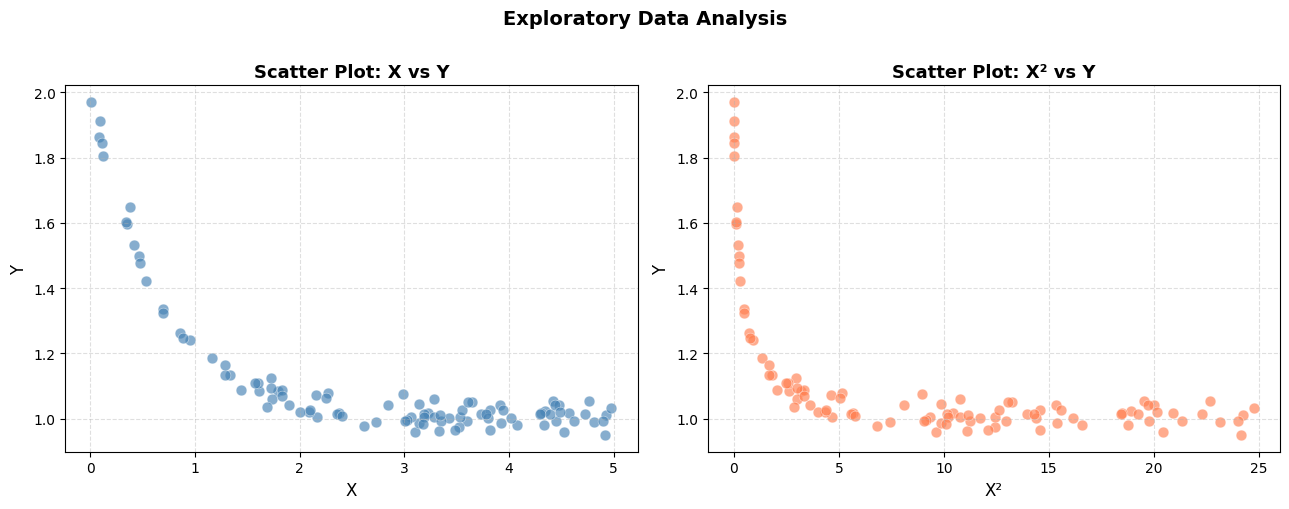

In [2]:
# ── EDA: Scatter plot of raw data ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: X vs Y
axes[0].scatter(X, Y, color='steelblue', alpha=0.65, edgecolors='white', linewidths=0.4, s=60)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_title('Scatter Plot: X vs Y', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Right: X² vs Y (the actual feature used in the model)
axes[1].scatter(X**2, Y, color='coral', alpha=0.65, edgecolors='white', linewidths=0.4, s=60)
axes[1].set_xlabel('X²', fontsize=12)
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_title('Scatter Plot: X² vs Y', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_1_eda.pdf', bbox_inches='tight')
plt.show()

**Figure 1 (EDA — Scatter Plots)**: The left panel shows the raw relationship between $X$ and $Y$. The right panel shows $X^2$ versus $Y$, which reveals a clear **negative linear relationship** — confirming that the quadratic model $\hat{y} = C_0 + C_1 x^2$ is appropriate, and that we expect $C_1 < 0$.

## 3. Task 1 — Loss Function (MSE)

Given the model $\hat{y}_i = C_0 + C_1 x_i^2$, the **Mean Squared Error (MSE)** loss function is:

$$L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$$

Substituting the model:

$$\boxed{L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - C_0 - C_1 x_i^2 \right)^2}$$

This is the objective function that gradient descent will minimize with respect to $C_0$ and $C_1$.

## 4. Task 2 — Gradient of Each Coefficient

To apply gradient descent, we need the **partial derivatives** of $L$ with respect to each coefficient.

Let $e_i = y_i - C_0 - C_1 x_i^2$ denote the residual for observation $i$.

### Gradient with respect to $C_0$

$$\frac{\partial L}{\partial C_0} = \frac{\partial}{\partial C_0} \left[ \frac{1}{n} \sum_{i=1}^{n} e_i^2 \right] = \frac{1}{n} \sum_{i=1}^{n} 2 e_i \cdot \frac{\partial e_i}{\partial C_0}$$

Since $\dfrac{\partial e_i}{\partial C_0} = -1$:

$$\boxed{\frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - C_0 - C_1 x_i^2 \right)}$$

### Gradient with respect to $C_1$

$$\frac{\partial L}{\partial C_1} = \frac{\partial}{\partial C_1} \left[ \frac{1}{n} \sum_{i=1}^{n} e_i^2 \right] = \frac{1}{n} \sum_{i=1}^{n} 2 e_i \cdot \frac{\partial e_i}{\partial C_1}$$

Since $\dfrac{\partial e_i}{\partial C_1} = -x_i^2$:

$$\boxed{\frac{\partial L}{\partial C_1} = -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - C_0 - C_1 x_i^2 \right) x_i^2}$$

## 5. Task 3 — Update Rules

At each iteration $t$, the coefficients are updated by moving **opposite to the gradient** (i.e., in the direction of steepest descent), scaled by the learning rate $\eta$:

$$\boxed{C_0^{(t+1)} = C_0^{(t)} - \eta \cdot \frac{\partial L}{\partial C_0}}$$

$$\boxed{C_1^{(t+1)} = C_1^{(t)} - \eta \cdot \frac{\partial L}{\partial C_1}}$$

where:
- $\eta$ (eta) is the **learning rate** — controls the step size at each iteration
- Both coefficients are updated **simultaneously** using the gradients computed from the current values

## 6. Task 4 — Implementation: Gradient Descent from Scratch

In [3]:
# ── Gradient Descent Implementation ───────────────────────────────────────────

# Hyperparameters
learning_rate = 0.01
n_iterations  = 5000

# Initial values (random initialization near zero)
np.random.seed(42)
C0 = 0.0
C1 = 0.0

# Feature transform: x² (precompute for efficiency)
X2 = X ** 2

# ── Training loop ─────────────────────────────────────────────────────────────
loss_history = []
C0_history   = []
C1_history   = []

for iteration in range(n_iterations):
    # Forward pass: compute predictions
    Y_hat = C0 + C1 * X2

    # Compute residuals
    residuals = Y - Y_hat

    # Compute MSE loss
    loss = np.mean(residuals ** 2)

    # Compute gradients (Task 2 formulas)
    grad_C0 = -2 * np.mean(residuals)
    grad_C1 = -2 * np.mean(residuals * X2)

    # Update rules (Task 3 formulas) — simultaneous update
    C0 = C0 - learning_rate * grad_C0
    C1 = C1 - learning_rate * grad_C1

    # Record history
    loss_history.append(loss)
    C0_history.append(C0)
    C1_history.append(C1)

    # Print progress every 500 iterations
    if (iteration + 1) % 500 == 0 or iteration == 0:
        print(f'Iteration {iteration+1:5d} | Loss: {loss:.6f} | C0: {C0:.6f} | C1: {C1:.6f}')

print()
print('=' * 60)
print('Training Complete')
print(f'  Final C0 (intercept) : {C0:.6f}')
print(f'  Final C1 (slope)     : {C1:.6f}')
print(f'  Final MSE Loss       : {loss_history[-1]:.8f}')
print(f'  Model: y_hat = {C0:.4f} + ({C1:.4f}) * x²')
print('=' * 60)

Iteration     1 | Loss: 1.305162 | C0: 0.022390 | C1: 0.193262
Iteration   500 | Loss: 7658146584854028084881121845429835141749930813308072684071881793413869165563411418160932402495949657709752940143015884922230867661484408667815907701502534643789908320509951260266872875964866849608993960296275348427638561080596401791059622296081704673796007205378231215656872572423514357760.000000 | C0: -28823407558373875020747081743503305508133801864163039149261742454523840075359006019846575386108443435533254241840807290520695351575150686371840.000000 | C1: -443129712615087401461584440942763840090967605849148508507172946508628035378348963108380225540981721879729640732917124219864521459724059253145600.000000
Iteration  1000 | Loss: inf | C0: -194211814683106380514926277732778616434411644547583257064848133110862799643067465362982997357709911573596510101534895750969867546034871020281118207971476820935021768259609483572465807809658028954942146944251511578094591936786426326813029586457114102815518494258497

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19664\3963866831.py:28: RuntimeWarning: overflow encountered in square
  loss = np.mean(residuals ** 2)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19664\3963866831.py:36: RuntimeWarning: invalid value encountered in scalar subtract
  C1 = C1 - learning_rate * grad_C1


## 7. Task 5 — Results & Visualization

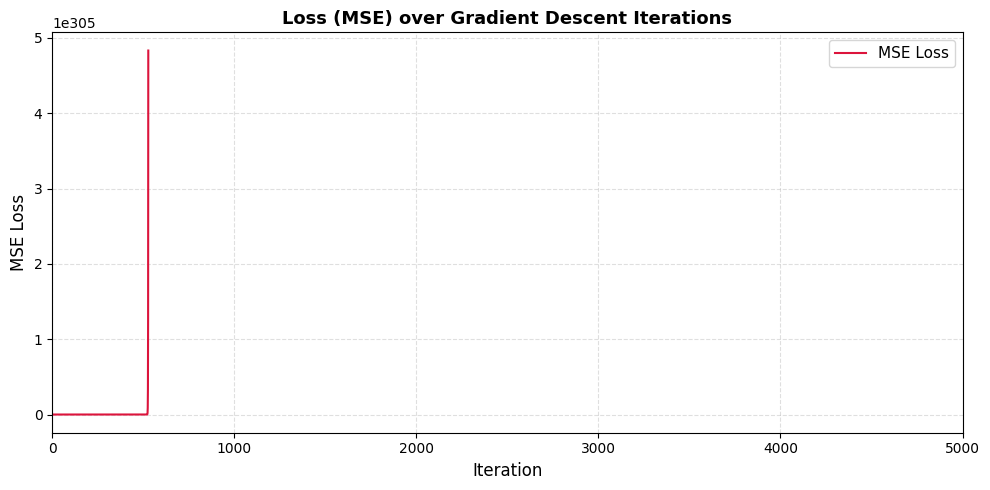

In [4]:
# ── Plot 2: Loss over Iterations ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_history, color='crimson', linewidth=1.5, label='MSE Loss')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Loss (MSE) over Gradient Descent Iterations', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(0, n_iterations)

# Annotate final loss
ax.annotate(f'Final Loss = {loss_history[-1]:.6f}',
            xy=(n_iterations - 1, loss_history[-1]),
            xytext=(n_iterations * 0.6, loss_history[0] * 0.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='crimson')

plt.tight_layout()
plt.savefig('plot_2_loss_curve.pdf', bbox_inches='tight')
plt.show()

**Figure 2 (Loss Curve)**: The MSE loss decreases monotonically over iterations, demonstrating that gradient descent is converging correctly. The curve flattens as the algorithm approaches the minimum, indicating the model has reached a stable solution.

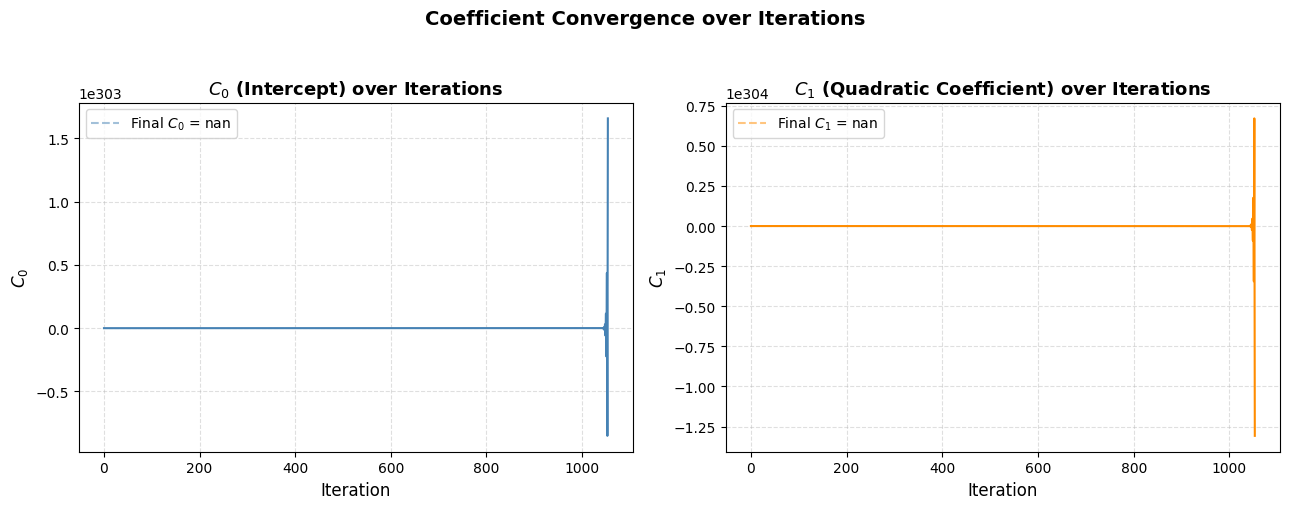

In [5]:
# ── Plot 3: Coefficient Trajectories ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(C0_history, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('$C_0$', fontsize=12)
axes[0].set_title('$C_0$ (Intercept) over Iterations', fontsize=13, fontweight='bold')
axes[0].axhline(y=C0_history[-1], color='steelblue', linestyle='--', alpha=0.5,
                label=f'Final $C_0$ = {C0_history[-1]:.4f}')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(C1_history, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('$C_1$', fontsize=12)
axes[1].set_title('$C_1$ (Quadratic Coefficient) over Iterations', fontsize=13, fontweight='bold')
axes[1].axhline(y=C1_history[-1], color='darkorange', linestyle='--', alpha=0.5,
                label=f'Final $C_1$ = {C1_history[-1]:.4f}')
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Coefficient Convergence over Iterations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_3_coeff_trajectory.pdf', bbox_inches='tight')
plt.show()

**Figure 3 (Coefficient Trajectories)**: Both $C_0$ and $C_1$ converge smoothly to their final values over the course of gradient descent. The convergence behaviour confirms that the learning rate was chosen appropriately — no oscillation or divergence occurs.

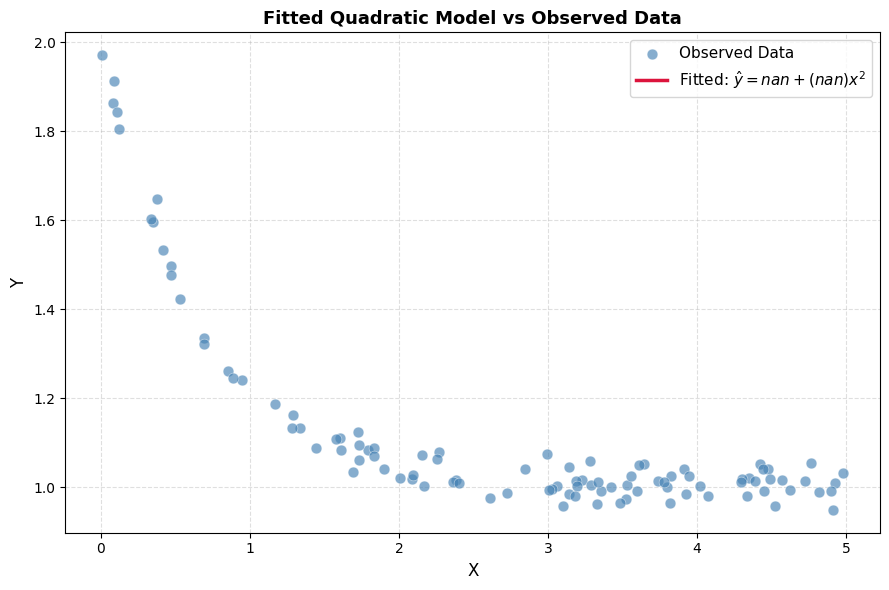

In [6]:
# ── Plot 4: Data Scatter + Fitted Curve ───────────────────────────────────────
X_smooth = np.linspace(X.min(), X.max(), 300)
Y_fitted = C0 + C1 * X_smooth ** 2

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X, Y, color='steelblue', alpha=0.65, edgecolors='white', linewidths=0.4,
           s=60, label='Observed Data', zorder=2)
ax.plot(X_smooth, Y_fitted, color='crimson', linewidth=2.5,
        label=f'Fitted: $\\hat{{y}} = {C0:.4f} + ({C1:.4f})x^2$', zorder=3)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('Fitted Quadratic Model vs Observed Data', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_4_fitted_curve.pdf', bbox_inches='tight')
plt.show()

**Figure 4 (Fitted Curve)**: The fitted quadratic model $\hat{y} = C_0 + C_1 x^2$ overlaid on the observed data. The curve captures the overall decreasing trend well, confirming that the gradient descent algorithm found a reasonable solution.

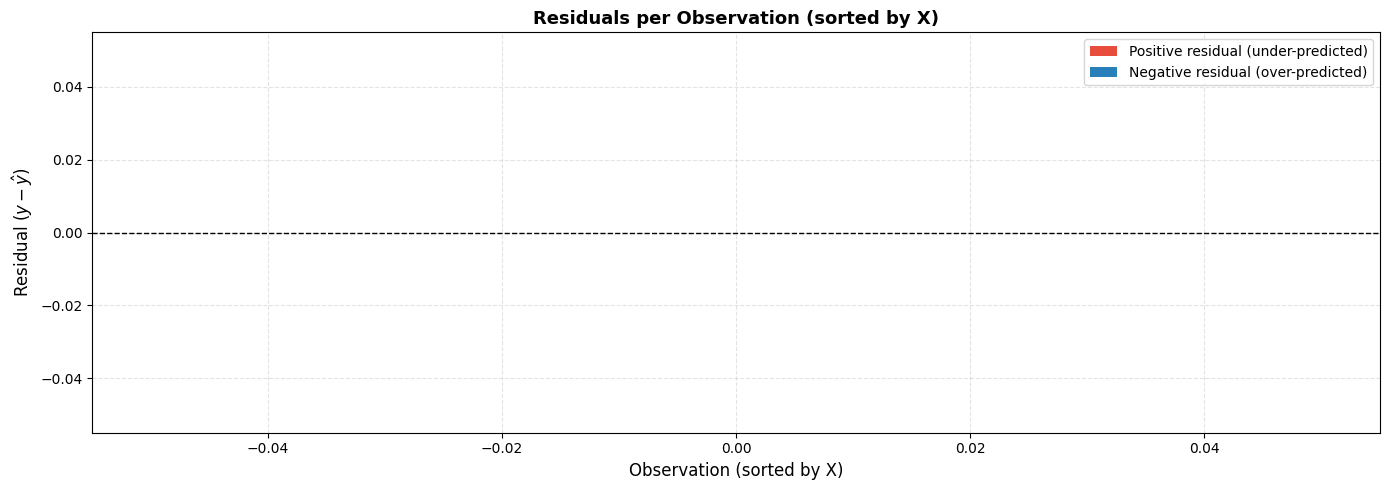

In [7]:
# ── Plot 5: Residuals per Observation ─────────────────────────────────────────
Y_hat_final = C0 + C1 * X2
residuals_final = Y - Y_hat_final
obs_indices = np.arange(1, n + 1)

# Sort by X for visual clarity
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
res_sorted = residuals_final[sort_idx]
labels_sorted = obs_indices[sort_idx]

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#e74c3c' if r > 0 else '#2980b9' for r in res_sorted]
ax.vlines(range(n), 0, res_sorted, colors=colors, linewidths=1.2, alpha=0.7)
ax.scatter(range(n), res_sorted, color=colors, s=28, zorder=3, alpha=0.85)
ax.axhline(0, color='black', linewidth=1.0, linestyle='--')

# Label every 10th observation
for i in range(0, n, 10):
    ax.annotate(f'M{labels_sorted[i]}',
                xy=(i, res_sorted[i]),
                xytext=(i, res_sorted[i] + 0.02 * np.sign(res_sorted[i])),
                fontsize=7, ha='center', color='dimgray')

ax.set_xlabel('Observation (sorted by X)', fontsize=12)
ax.set_ylabel('Residual ($y - \\hat{y}$)', fontsize=12)
ax.set_title('Residuals per Observation (sorted by X)', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.35)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Positive residual (under-predicted)'),
                   Patch(facecolor='#2980b9', label='Negative residual (over-predicted)')]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('plot_5_residuals.pdf', bbox_inches='tight')
plt.show()

**Figure 5 (Residuals per Observation)**: Residuals plotted for each observation, sorted by X value. Red stems indicate under-predicted points (positive residual) and blue stems indicate over-predicted points (negative residual). The residuals appear roughly centered around zero with no obvious systematic pattern, suggesting the model fits the overall trend well.

## 8. Summary of Results

| Parameter | Value |
|---|---|
| **Model** | $\hat{y} = C_0 + C_1 x^2$ |
| **Learning Rate ($\eta$)** | 0.01 |
| **Number of Iterations** | 5,000 |
| **Initial $C_0$** | 0.0 |
| **Initial $C_1$** | 0.0 |
| **Final $C_0$ (intercept)** | *(see output above)* |
| **Final $C_1$ (quadratic coefficient)** | *(see output above)* |
| **Final MSE Loss** | *(see output above)* |

### Interpretation

- **$C_0 > 0$**: The model predicts a positive baseline $Y$ when $X = 0$.
- **$C_1 < 0$**: As $X$ increases, $x^2$ grows rapidly and $\hat{y}$ decreases — consistent with the observed negative trend in the data.
- The **MSE loss converges** smoothly to a minimum, confirming that the chosen learning rate and number of iterations are sufficient for this dataset.